# Restoration demo: one good case, one bad case

A quick demo for the progress presentation (slide 4). It loads only the frozen ResNet-50 (no depth model), so it runs in well under a minute.

For each example: **clean image → damaged image → classical restoration (oracle: told the true damage) → frozen ResNet-50**.

- **Good:** *brighten* is a reversible transform. The object is still in the pixels, so restoration can undo it.
- **Bad:** *Gaussian noise* destroys fine detail. The denoiser has to estimate what was there, and it wipes out the texture ResNet relies on.

Both images are from the full run and are **ImageNet validation images** (`ILSVRC2012_val_*`), so ResNet-50 never trained on them.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make `src/bolero` importable from wherever the notebook is opened.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "bolero").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from bolero.classifier import FrozenClassifier
from bolero.config import IMAGENETTE_CLASSES, IMAGENETTE_INDEX, SEED, find_imagenette_root
from bolero.data import load_image
from bolero.perturbations import PERTURBATIONS, rng_for
from bolero.restoration import PLANS, restore

classifier = FrozenClassifier()
root = find_imagenette_root()
print("device:", classifier.device, "| data:", root)

/opt/anaconda3/envs/projects/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 320/320 [00:00<00:00, 48900.69it/s]

device: mps | data: /Users/venkat/Desktop/Masters/ASU/Classes/ODM/clip_corruption_calibration/data/imagenette2-160


In [2]:
WNID = {name: wnid for wnid, name in IMAGENETTE_CLASSES.items()}

def short(label: str) -> str:
    return label.split(",")[0]

def run_example(image_id: str, class_name: str, perturbation: str, level: int = 3):
    wnid = WNID[class_name]
    clean = load_image(root / "val" / wnid / f"{image_id}.JPEG")
    # Same seeded damage as the full run, so the result matches results/restoration.
    damaged = PERTURBATIONS[perturbation](clean, level, rng=rng_for(image_id, perturbation, level, SEED))
    restored = restore(damaged, perturbation)

    images = [clean, damaged, restored]
    preds = classifier.predict(images, np.full(3, IMAGENETTE_INDEX[wnid]))
    plan = " + ".join(op.__name__ for op in PLANS[perturbation])
    titles = ["1. clean", f"2. {perturbation} (level {level})", f"3. restored ({plan})"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4.3))
    for ax, im, title, idx, conf in zip(axes, images, titles, preds.index, preds.confidence):
        ok = idx == IMAGENETTE_INDEX[wnid]
        ax.imshow(im)
        ax.set_title(title, fontsize=11)
        ax.set_xlabel(f"{short(classifier.id2label[int(idx)])} ({conf:.0%}) {'✓' if ok else '✗'}",
                      color="tab:green" if ok else "tab:red", fontsize=12, fontweight="bold")
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"True class: {class_name}", fontsize=13)
    plt.tight_layout(); plt.show()
    return images

## Good example: brightening (reversible)

Brightening squeezes every pixel toward white, but it keeps the pixels in the same order. The auto-levels stretch maps the range back out, so the evidence comes back and so does the label.

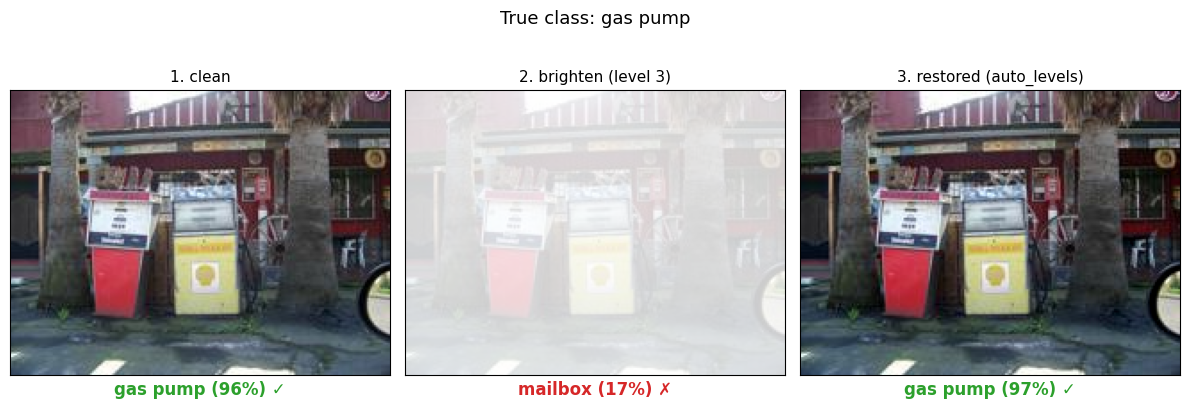

In [3]:
good = run_example("ILSVRC2012_val_00004860", "gas pump", "brighten")

## Bad example: Gaussian noise (information is lost)

Here the damaged image is still classified correctly, because ResNet can see the object's structure through the noise. The denoiser (non-local means) removes the noise **and** the fine texture with it. The smoothed result no longer looks like a chain saw to the model, so restoration turns a correct answer into a wrong one.

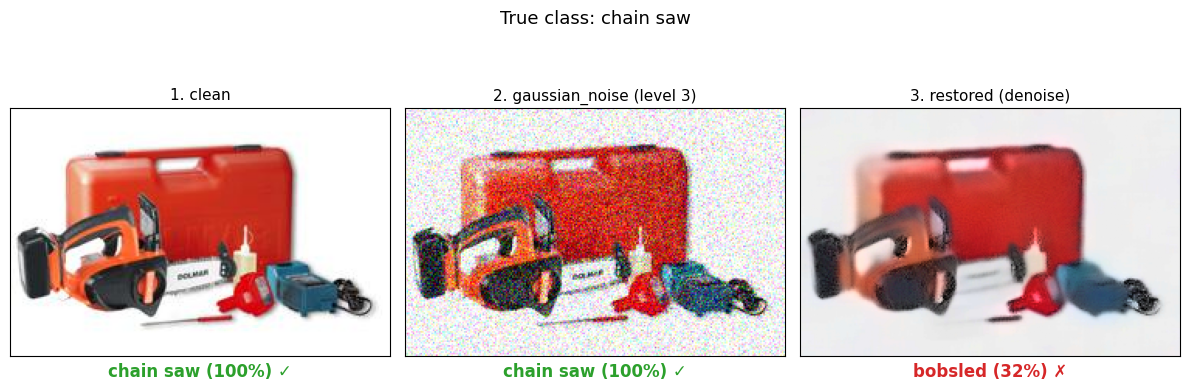

In [4]:
bad = run_example("ILSVRC2012_val_00011951", "chain saw", "gaussian_noise")

### Why: zoom in on the saw

In the noisy image the blade, its edge and the "DOLMAR" lettering are still visible under the noise, which is why ResNet still says *chain saw*. After denoising, the blade and the lettering are smeared away. What is left is a smooth orange-and-white shape, and ResNet reads that as a bobsled.

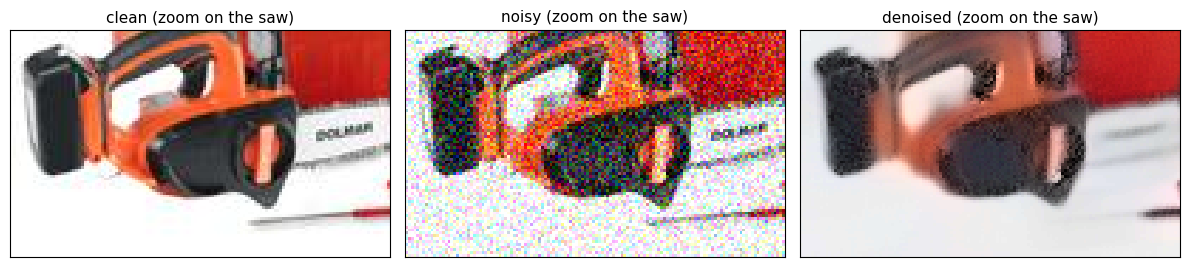

In [5]:
h, w = bad[0].shape[:2]
crop = (slice(int(h * 0.45), int(h * 0.95)), slice(0, int(w * 0.55)))  # the chain saw itself

fig, axes = plt.subplots(1, 3, figsize=(12, 4.3))
for ax, im, title in zip(axes, bad, ["clean", "noisy", "denoised"]):
    ax.imshow(im[crop], interpolation="nearest")
    ax.set_title(f"{title} (zoom on the saw)", fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Takeaway

- **Reversible damage** (brighten, blur, inversion): the information is still in the image, and restoration recovers it. Gains are about +3 to +5 points across 500 images.
- **Destructive damage** (noise, missing regions): restoration has to estimate missing content and makes things worse, by up to −20 points.
- So the system needs to know **when not to restore**.